<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/904085103.py:35: SyntaxWarning: invalid escape sequence '\s'
  spectra = [preprocess(pd.read_csv(p, sep='\s+', header=None, names=["mz", "intensity"])) for p in paths]


✅ 使用设备: cpu


⚙️ 对齐所有样本点: 100%|██████████| 276/276 [00:01<00:00, 181.35it/s]
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/904085103.py:96: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/904085103.py:96: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/904085103.py:96: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/904085103.py:96: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/904085103.py:96: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font

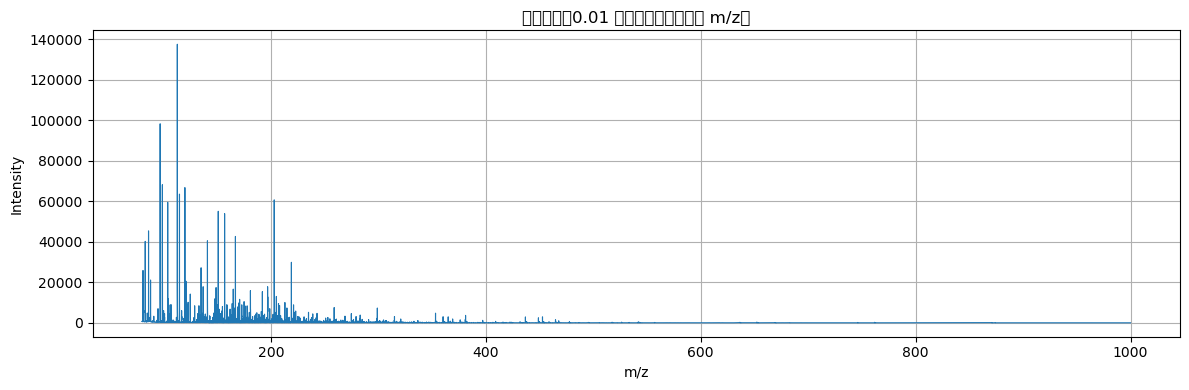

In [2]:
#不执行
import os
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# ===== 设置路径与GPU =====
current_dir = os.getcwd()
txt_folder = current_dir + "/txt" # ✅ 替换为你的实际路径
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ 使用设备:", device)

# ===== 读取并按样本点分组（如 G1）=====
file_paths = [os.path.join(txt_folder, f) for f in os.listdir(txt_folder) if f.endswith('.txt')]
sample_groups = {}
for path in file_paths:
    name = os.path.basename(path)
    parts = name.split('_')
    group_id = parts[2]  # e.g. G1
    sample_groups.setdefault(group_id, []).append(path)

# ===== 预处理函数（平滑 + 基线）=====
def preprocess(df):
    y = df['intensity'].values
    smoothed = savgol_filter(y, window_length=11, polyorder=3)
    baseline_corrected = smoothed - np.min(smoothed)
    return pd.DataFrame({'mz': df['mz'], 'intensity': baseline_corrected})

# ===== 每个样本点求平均谱图（内插到统一 m/z）=====
avg_spectra = []
for group, paths in tqdm(sample_groups.items(), desc="📂 平均每个样本点"):
    spectra = [preprocess(pd.read_csv(p, sep='\s+', header=None, names=["mz", "intensity"])) for p in paths]
    all_mz = np.unique(np.concatenate([s['mz'].values for s in spectra]))
    all_mz_tensor = torch.tensor(all_mz, dtype=torch.float32, device=device)
    interp_intensities = []
    for s in spectra:
        mz = torch.tensor(s['mz'].values, dtype=torch.float32, device=device)
        intensity = torch.tensor(s['intensity'].values, dtype=torch.float32, device=device)
        idx = torch.searchsorted(mz, all_mz_tensor)
        idx = torch.clamp(idx, 1, len(mz)-1)
        x0 = mz[idx - 1]
        x1 = mz[idx]
        y0 = intensity[idx - 1]
        y1 = intensity[idx]
        interp = y0 + (y1 - y0) * (all_mz_tensor - x0) / (x1 - x0 + 1e-8)
        interp_intensities.append(interp)
    mean_intensity = torch.stack(interp_intensities).mean(dim=0)
    avg_spectra.append((all_mz_tensor.cpu().numpy(), mean_intensity.cpu().numpy()))

# ===== 整合所有样本点的 m/z，再统一对齐并求平均 =====
ref_mz = np.unique(np.concatenate([mz for mz, _ in avg_spectra]))
ref_mz_tensor = torch.tensor(ref_mz, dtype=torch.float32, device=device)
aligned_all = []

for mz_arr, int_arr in tqdm(avg_spectra, desc="⚙️ 对齐所有样本点"):
    mz = torch.tensor(mz_arr, dtype=torch.float32, device=device)
    intensity = torch.tensor(int_arr, dtype=torch.float32, device=device)
    idx = torch.searchsorted(mz, ref_mz_tensor)
    idx = torch.clamp(idx, 1, len(mz)-1)
    x0 = mz[idx - 1]
    x1 = mz[idx]
    y0 = intensity[idx - 1]
    y1 = intensity[idx]
    interp = y0 + (y1 - y0) * (ref_mz_tensor - x0) / (x1 - x0 + 1e-8)
    aligned_all.append(interp)

ref_intensity_tensor = torch.stack(aligned_all).mean(dim=0)
ref_intensity = ref_intensity_tensor.cpu().numpy()

# ===== 合并相近的 m/z 到统一分辨率（0.01） =====
ref_mz_rounded = np.round(ref_mz / 0.01) * 0.01
df_temp = pd.DataFrame({
    "mz": ref_mz_rounded,
    "intensity": ref_intensity
})
ref_spectrum = df_temp.groupby("mz", as_index=False).mean()
# === 按每 1 m/z 区间保留最强点 ===
ref_spectrum['mz_bin'] = np.floor(ref_spectrum['mz'])  # 分 bin，如 89.91 → 89.0

# 保留每个 bin 内 intensity 最大的点（保留原始 m/z 值）
ref_spectrum_sparse = ref_spectrum.loc[
    ref_spectrum.groupby('mz_bin')['intensity'].idxmax()
].sort_values(by='mz').reset_index(drop=True)


# ===== 绘制参考谱图 =====
plt.figure(figsize=(12, 4))
plt.plot(ref_spectrum["mz"], ref_spectrum["intensity"], lw=0.8)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("参考谱图（0.01 分辨率，已合并相近 m/z）")
plt.grid(True)
plt.tight_layout()
plt.show()



/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2141765458.py:31: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2141765458.py:31: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2141765458.py:31: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2141765458.py:31: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2141765458.py:31: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/chenshisi/min

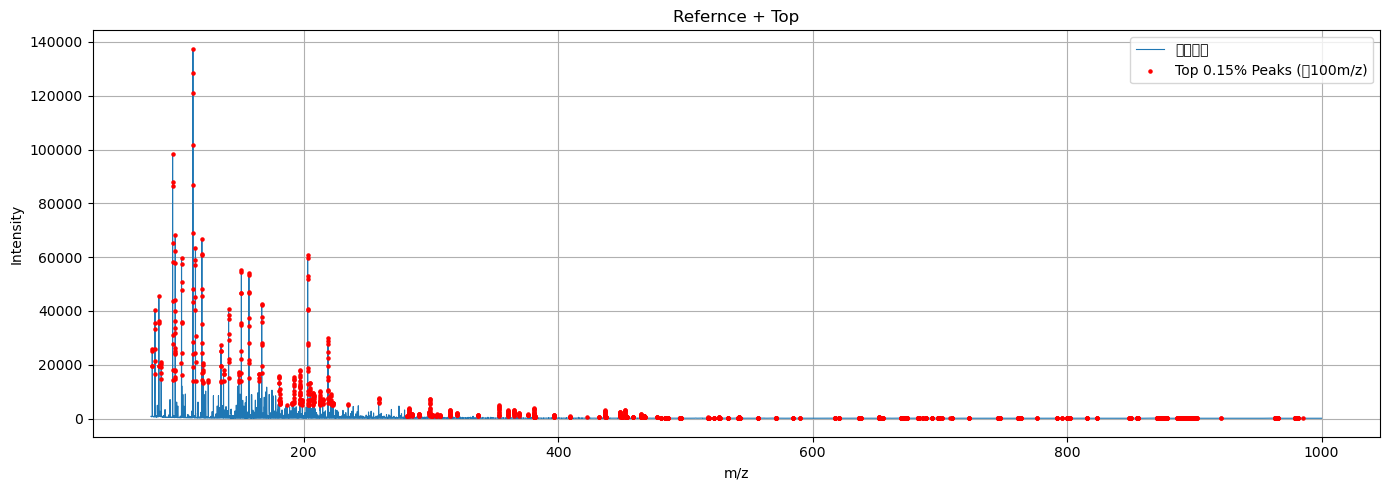

In [5]:
#不执行
# ===== 设置参数 =====
segment_width = 100
top_frac = 0.015

# ===== 提取参考谱峰 =====
mz_min, mz_max = ref_spectrum['mz'].min(), ref_spectrum['mz'].max()
peaks = []

for start in np.arange(mz_min, mz_max, segment_width):
    end = start + segment_width
    segment = ref_spectrum[(ref_spectrum['mz'] >= start) & (ref_spectrum['mz'] < end)]
    if len(segment) == 0:
        continue
    top_n = max(1, int(len(segment) * top_frac))
    segment_top = segment.nlargest(top_n, 'intensity')
    peaks.append(segment_top)

# 合并所有段的 top 峰
peaks_df = pd.concat(peaks).sort_values(by='mz').reset_index(drop=True)

# ===== 绘图 + 标注峰位置 =====
plt.figure(figsize=(14, 5))
plt.plot(ref_spectrum["mz"], ref_spectrum["intensity"], lw=0.8, label="参考谱图")
plt.scatter(peaks_df["mz"], peaks_df["intensity"], color='red', s=5, label="Top 0.15% Peaks (每100m/z)", zorder=3)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Refernce + Top")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


构建全局 m/z 网格...
开始构建参考谱图...


/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/540094309.py:76: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/540094309.py:76: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/540094309.py:76: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/540094309.py:76: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/540094309.py:76: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11

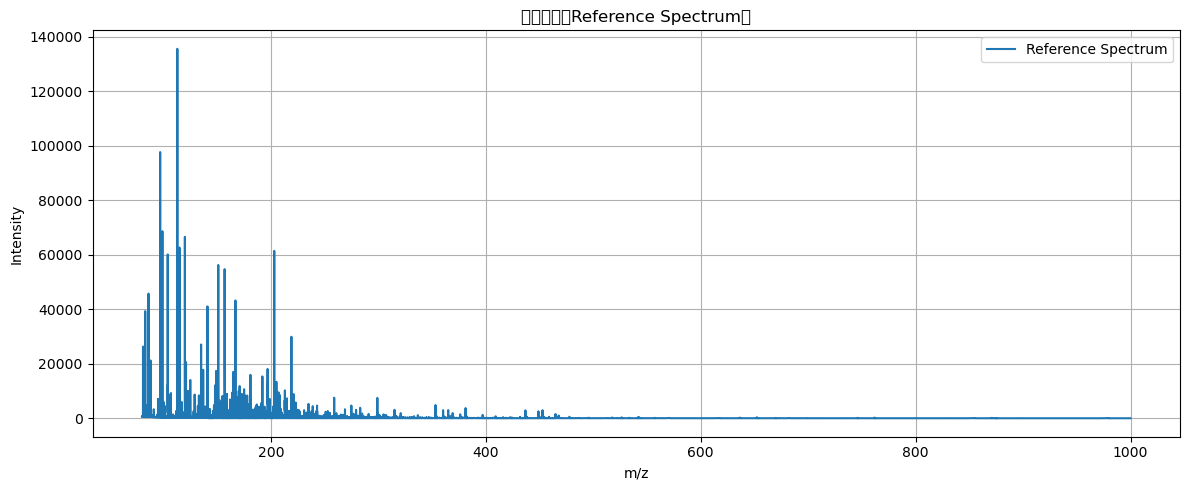

In [7]:
# 📌 Step 1: 导入库
import os
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 📌 Step 2: 配置参数
current_dir = os.getcwd()
DATA_FOLDER = current_dir+"/txt"   # ← 修改为你的文件夹路径
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MZ_RESOLUTION = 0.01  # m/z 网格分辨率

# 📌 Step 3: 读取所有文件并归类
def parse_filename(filename):
    match = re.match(r"samples_\d+_(\w+)_\d+\.txt", filename)
    return match.group(1) if match else None

all_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith('.txt')]
sample_dict = {}
for fname in all_files:
    sample_id = parse_filename(fname)
    if sample_id:
        sample_dict.setdefault(sample_id, []).append(os.path.join(DATA_FOLDER, fname))

# 检查是否每个样本有 5 份
sample_dict = {k: v for k, v in sample_dict.items() if len(v) == 5}

# 📌 Step 4: 加载单个谱图
def load_spectrum(path):
    data = np.loadtxt(path)
    return data[:, 0], data[:, 1]

# 📌 Step 5: 统一网格构建
print("构建全局 m/z 网格...")
all_mz_values = []
for files in sample_dict.values():
    for f in files:
        mz, _ = load_spectrum(f)
        all_mz_values.append(mz)
all_mz = np.unique(np.concatenate(all_mz_values))
mz_min, mz_max = np.min(all_mz), np.max(all_mz)
grid_mz = np.arange(mz_min, mz_max, MZ_RESOLUTION)
grid_mz_torch = torch.tensor(grid_mz, dtype=torch.float32, device=DEVICE)

# 📌 Step 6: 对每个样本点求平均谱图（重采样）
def average_sample_spectrum(paths, grid_mz):
    interpolated_list = []
    for path in paths:
        mz, intensity = load_spectrum(path)
        f = interp1d(mz, intensity, bounds_error=False, fill_value=0)
        interpolated = f(grid_mz)
        interpolated_list.append(interpolated)
    tensor = torch.tensor(np.stack(interpolated_list), dtype=torch.float32, device=DEVICE)
    return torch.mean(tensor, dim=0)

# 📌 Step 7: 构建参考谱图
print("开始构建参考谱图...")
avg_specs = []
for sample_id, paths in sample_dict.items():
    avg_spec = average_sample_spectrum(paths, grid_mz)
    avg_specs.append(avg_spec)

avg_specs_tensor = torch.stack(avg_specs)
ref_spectrum = torch.mean(avg_specs_tensor, dim=0).detach().cpu().numpy()

# 📌 Step 8: 可视化
plt.figure(figsize=(12, 5))
plt.plot(grid_mz, ref_spectrum, label='Reference Spectrum')
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("参考谱图（Reference Spectrum）")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/330845200.py:55: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/330845200.py:55: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/330845200.py:55: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/330845200.py:55: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/330845200.py:55: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11

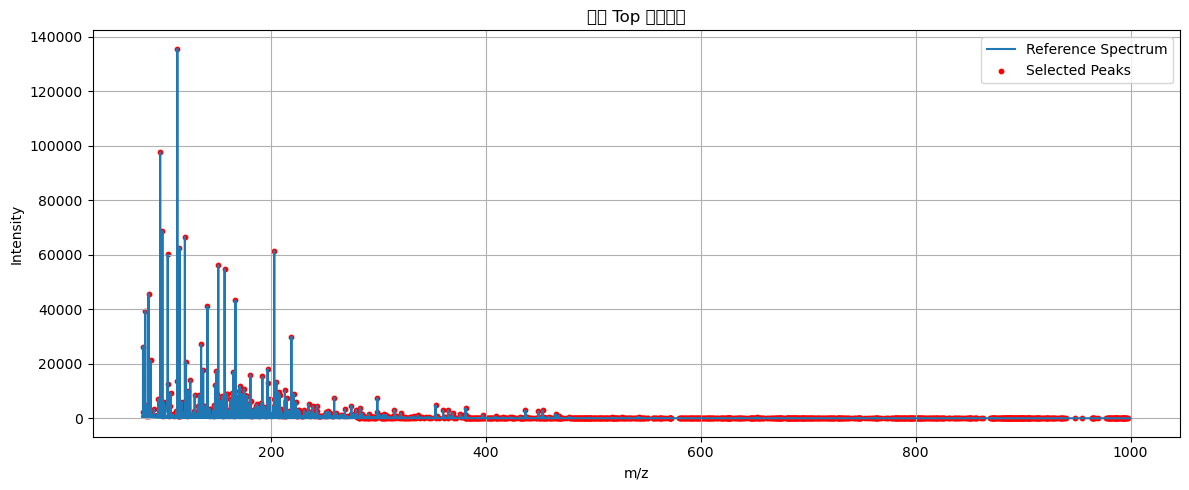

In [8]:
# 📌 Step 9: 局部 Top 峰提取函数
def extract_local_top_peaks(mz_grid, spectrum, window_size=100, top_k_ratio=0.0015, merge_tol=0.05):
    mz_grid = np.array(mz_grid)
    spectrum = np.array(spectrum)
    
    min_mz = np.min(mz_grid)
    max_mz = np.max(mz_grid)
    
    peak_mz_list = []
    peak_int_list = []

    current_start = min_mz
    while current_start < max_mz:
        current_end = current_start + window_size
        mask = (mz_grid >= current_start) & (mz_grid < current_end)
        mz_sub = mz_grid[mask]
        int_sub = spectrum[mask]

        if len(int_sub) == 0:
            current_start = current_end
            continue

        top_k = max(1, int(len(int_sub) * top_k_ratio))
        top_indices = np.argsort(int_sub)[-top_k:]
        peak_mz_list.extend(mz_sub[top_indices])
        peak_int_list.extend(int_sub[top_indices])

        current_start = current_end

    # 合并邻近峰（避免重复）
    sorted_peaks = sorted(zip(peak_mz_list, peak_int_list), key=lambda x: x[0])
    filtered_peaks = []
    for mz, inten in sorted_peaks:
        if not filtered_peaks or abs(mz - filtered_peaks[-1][0]) > merge_tol:
            filtered_peaks.append((mz, inten))
        elif inten > filtered_peaks[-1][1]:
            filtered_peaks[-1] = (mz, inten)  # 保留强度更高者

    peak_mz_final = np.array([x[0] for x in filtered_peaks])
    peak_int_final = np.array([x[1] for x in filtered_peaks])
    return peak_mz_final, peak_int_final

# 📌 Step 10: 提取峰
peak_mz, peak_int = extract_local_top_peaks(grid_mz, ref_spectrum, window_size=100, top_k_ratio=0.15, merge_tol=0.1)
ref_peak_mz = peak_mz
# 📌 Step 11: 可视化峰位置
plt.figure(figsize=(12, 5))
plt.plot(grid_mz, ref_spectrum, label='Reference Spectrum')
plt.scatter(peak_mz, peak_int, color='red', s=10, label='Selected Peaks')
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("局部 Top 谱峰提取")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2485012579.py:111: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2485012579.py:111: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2485012579.py:111: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2485012579.py:111: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/2485012579.py:111: UserWarning: Glyph 40784 (\N{CJK UNIFIED IDEOGRAPH-9F50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw

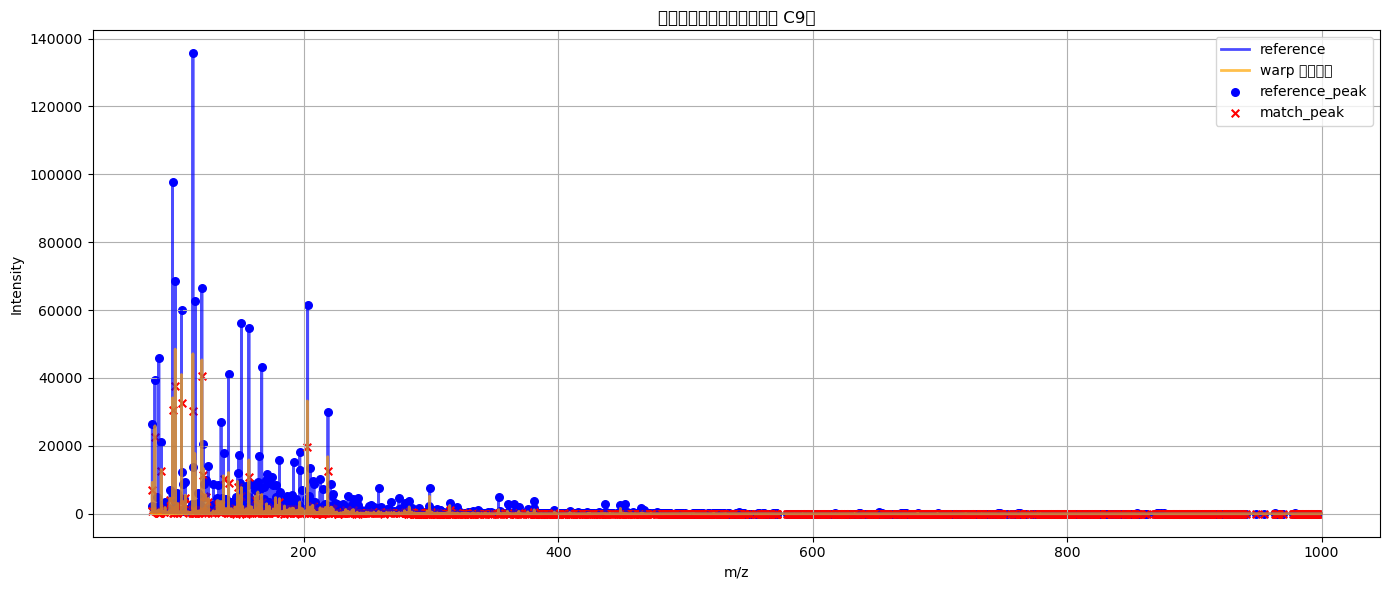

🎯 当前处理样本组编号: C9
前10个匹配参考峰的皮尔逊相关系数：
[0.952 0.978 0.951 0.999 0.955 0.968 0.962 0.912 0.932 0.779]


In [9]:
#可不执行
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.stats import pearsonr

# ✅ 配置路径
current_dir = os.getcwd()
DATA_FOLDER = current_dir+"/txt"  # ← 替换为你的数据路径
MZ_RESOLUTION = 0.01
WINDOW = 0.5
KERNEL_SIZE = 10

# ✅ 工具函数
def parse_filename(filename):
    match = re.match(r"samples_\d+_(\w+)_\d+\.txt", filename)
    return match.group(1) if match else None

def load_spectrum(path):
    data = np.loadtxt(path)
    return data[:, 0], data[:, 1]

def match_peaks(test_mz, test_int, ref_peak_mz, window=0.5, kernel_size=10, res=0.01):
    interp = interp1d(test_mz, test_int, bounds_error=False, fill_value=0)
    offsets, scores = [], []
    for mz_ref in ref_peak_mz:
        kernel_mz = np.linspace(mz_ref - kernel_size/2*res, mz_ref + kernel_size/2*res, kernel_size)
        kernel_int = interp(kernel_mz)
        if np.all(kernel_int == 0): offsets.append(np.nan); scores.append(0); continue
        max_score, best_offset = -1, 0
        for center in np.linspace(mz_ref - window, mz_ref + window, 100):
            sub_mz = np.linspace(center - kernel_size/2*res, center + kernel_size/2*res, kernel_size)
            sub_int = interp(sub_mz)
            if np.all(sub_int == 0): continue
            r, _ = pearsonr(kernel_int, sub_int)
            if np.isnan(r): r = 0
            if r > max_score: max_score = r; best_offset = center - mz_ref
        offsets.append(best_offset)
        scores.append(max_score)
    return np.array(offsets), np.array(scores)

# ✅ 自动选择一组具有5个重复的样本组
all_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith(".txt")]
sample_dict = {}
for f in all_files:
    sid = parse_filename(f)
    if sid:
        sample_dict.setdefault(sid, []).append(f)

selected_id = None
for sid, flist in sample_dict.items():
    if len(flist) == 5:
        selected_id = sid
        break
assert selected_id is not None, "❌ 没有找到任何一组有5个重复的样本！"

# ✅ 读取该组数据并插值到 grid_mz，做平均
paths = [os.path.join(DATA_FOLDER, f) for f in sample_dict[selected_id]]
spectra = []
for p in paths:
    mz, inten = load_spectrum(p)
    f = interp1d(mz, inten, bounds_error=False, fill_value=0)
    spectra.append(f(grid_mz))
avg_spectrum = np.mean(np.stack(spectra), axis=0)

# ✅ 匹配参考峰
offsets, scores = match_peaks(grid_mz, avg_spectrum, ref_peak_mz, window=WINDOW, kernel_size=KERNEL_SIZE, res=MZ_RESOLUTION)

# ✅ 拟合 warp 函数
valid = ~np.isnan(offsets)
if np.sum(valid) > 5:
    warp_func = CubicSpline(ref_peak_mz[valid], ref_peak_mz[valid] + offsets[valid])
else:
    warp_func = lambda x: x  # fallback

# ✅ 重新计算真实 m/z 和强度均值（避免过早插值）
raw_mz_all = []
raw_int_all = []
for p in paths:
    mz, inten = load_spectrum(p)
    raw_mz_all.append(mz)
    raw_int_all.append(inten)
avg_mz = np.mean(np.stack(raw_mz_all), axis=0)
avg_int = np.mean(np.stack(raw_int_all), axis=0)
warped_mz = warp_func(avg_mz)
f_aligned = interp1d(warped_mz, avg_int, bounds_error=False, fill_value=0)
aligned_int = f_aligned(grid_mz)

# ✅ 可视化：谱图 + 参考峰 + 匹配峰
ref_peak_y = np.interp(ref_peak_mz, grid_mz, ref_spectrum)
matched_peak_mz = ref_peak_mz + offsets
matched_peak_y = np.interp(matched_peak_mz, grid_mz, aligned_int)

plt.figure(figsize=(14, 6))
plt.plot(grid_mz, ref_spectrum, label="reference", linewidth=2, alpha=0.7, color='blue')
plt.plot(grid_mz, aligned_int, label="warp 校正谱图", linewidth=2, alpha=0.7, color='orange')

# 参考谱峰（蓝点）
plt.scatter(ref_peak_mz, ref_peak_y, color='blue', s=30, marker='o', label='reference_peak')

# 样本匹配峰（红叉）
plt.scatter(matched_peak_mz, matched_peak_y, color='red', s=30, marker='x', label='match_peak')

plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"谱图峰对齐可视化（样本组 {selected_id}）")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ 输出匹配情况
print(f"🎯 当前处理样本组编号: {selected_id}")
print("前10个匹配参考峰的皮尔逊相关系数：")
print(np.round(scores[:10], 3))


/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/316273617.py:52: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/316273617.py:52: UserWarning: Glyph 36136 (\N{CJK UNIFIED IDEOGRAPH-8D28}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/316273617.py:52: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/316273617.py:52: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/316273617.py:52: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dw/0jy4mgm11

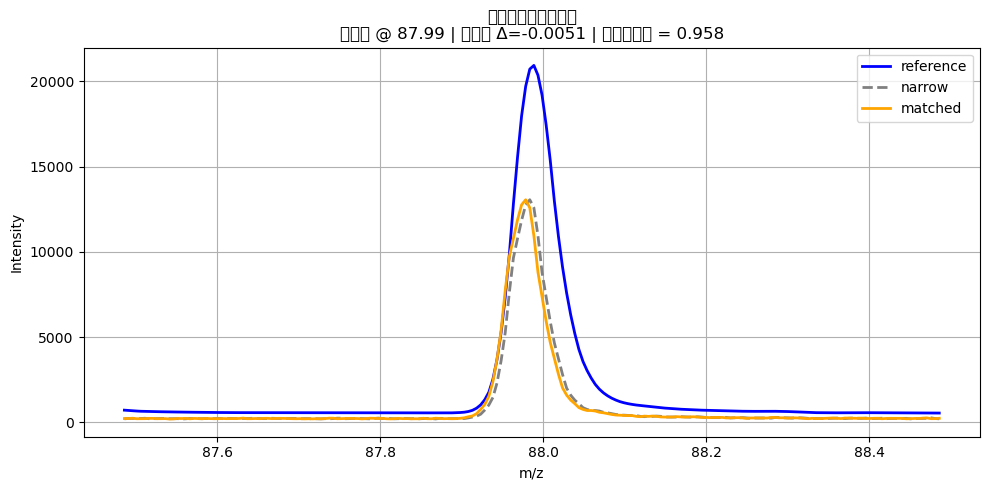

In [10]:
#可不执行
# ✅ 计算所有峰的参考强度和匹配强度
ref_peak_y = np.interp(ref_peak_mz, grid_mz, ref_spectrum)
matched_peak_mz = ref_peak_mz + offsets
matched_peak_y = np.interp(matched_peak_mz, grid_mz, aligned_int)
delta_mz = np.abs(offsets)

# ✅ 筛选出满足“强度高 + 偏移小 + 匹配得分高”的峰
score_thresh = 0.8
int_thresh = np.percentile(ref_peak_y, 80)  # 参考谱图中前 20% 的强峰
offset_thresh = 0.1

candidates = np.where(
    (ref_peak_y > int_thresh) &
    (matched_peak_y > int_thresh) &
    (scores > score_thresh) &
    (delta_mz < offset_thresh)
)[0]

assert len(candidates) > 0, "❌ 没有找到满足条件的高质量匹配峰！"

# ✅ 选第一个合适的候选峰
chosen_idx = candidates[2]
mz_ref = ref_peak_mz[chosen_idx]
offset = offsets[chosen_idx]
mz_match = mz_ref + offset

# ✅ 提取局部曲线
window_half = 0.5
mz_local = np.linspace(mz_ref - window_half, mz_ref + window_half, 200)

ref_local_int = np.interp(mz_local, grid_mz, ref_spectrum)
avg_raw_func = interp1d(avg_mz, avg_int, bounds_error=False, fill_value=0)
raw_local_int = avg_raw_func(mz_local)
warp_local_func = interp1d(warped_mz, avg_int, bounds_error=False, fill_value=0)
warp_local_int = warp_local_func(mz_local)

# ✅ 可视化
plt.figure(figsize=(10, 5))
plt.plot(mz_local, ref_local_int, label="reference", color='blue', linewidth=2)
plt.plot(mz_local, raw_local_int, label="narrow", color='gray', linestyle='--', linewidth=2)
plt.plot(mz_local, warp_local_int, label="matched", color='orange', linewidth=2)

plt.title(
    f"高质量峰对齐可视化\n"
    f"参考峰 @ {mz_ref:.2f} | 偏移量 Δ={offset:.4f} | 皮尔逊相关 = {scores[chosen_idx]:.3f}"
)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [11]:
import os
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d, CubicSpline
from scipy.stats import pearsonr

# ✅ 参数配置
current_dir = os.getcwd()
DATA_FOLDER = current_dir+"/txt"  # 修改为你的数据路径
WINDOW = 0.5
KERNEL_SIZE = 10
MZ_RESOLUTION = 0.01

# ✅ 你应该已经构建好以下变量：
# grid_mz        ← m/z 统一网格 (np.array)
# ref_spectrum   ← 参考谱图强度 (np.array)
# ref_peak_mz    ← 提取出的参考谱峰位置 (np.array)

# ✅ 文件名解析函数
def parse_filename(filename):
    match = re.match(r"samples_\d+_(\w+)_\d+\.txt", filename)
    return match.group(1) if match else None

# ✅ 加载单个谱图
def load_spectrum(path):
    data = np.loadtxt(path)
    return data[:, 0], data[:, 1]

# ✅ 匹配参考峰（返回 offset & 皮尔逊得分）
def match_peaks(test_mz, test_int, ref_peak_mz, window, kernel_size, res):
    interp = interp1d(test_mz, test_int, bounds_error=False, fill_value=0)
    offsets, scores = [], []
    for mz_ref in ref_peak_mz:
        kernel_mz = np.linspace(mz_ref - kernel_size/2*res, mz_ref + kernel_size/2*res, kernel_size)
        kernel_int = interp(kernel_mz)
        if np.all(kernel_int == 0): offsets.append(np.nan); scores.append(0); continue
        max_score, best_offset = -1, 0
        for center in np.linspace(mz_ref - window, mz_ref + window, 100):
            sub_mz = np.linspace(center - kernel_size/2*res, center + kernel_size/2*res, kernel_size)
            sub_int = interp(sub_mz)
            if np.all(sub_int == 0): continue
            r, _ = pearsonr(kernel_int, sub_int)
            if np.isnan(r): r = 0
            if r > max_score: max_score = r; best_offset = center - mz_ref
        offsets.append(best_offset)
        scores.append(max_score)
    return np.array(offsets), np.array(scores)

# ✅ 分组所有样本
all_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith(".txt")]
sample_dict = {}
for f in all_files:
    sid = parse_filename(f)
    if sid:
        sample_dict.setdefault(sid, []).append(f)
sample_dict = {k: v for k, v in sample_dict.items() if len(v) == 5}

# ✅ 批量处理样本
results = []
for sid, flist in tqdm(sample_dict.items(), desc="批量处理样本"):
    paths = [os.path.join(DATA_FOLDER, f) for f in flist]

    # 加载5个重复谱图
    raw_mz_all, raw_int_all = [], []
    for p in paths:
        mz, inten = load_spectrum(p)
        raw_mz_all.append(mz)
        raw_int_all.append(inten)

    # 平均后用于匹配参考峰
    avg_mz = np.mean(np.stack(raw_mz_all), axis=0)
    avg_int = np.mean(np.stack(raw_int_all), axis=0)
    avg_interp = interp1d(avg_mz, avg_int, bounds_error=False, fill_value=0)
    avg_on_grid = avg_interp(grid_mz)

    # warp 拟合
    offsets, scores = match_peaks(grid_mz, avg_on_grid, ref_peak_mz,
                                   window=WINDOW, kernel_size=KERNEL_SIZE, res=MZ_RESOLUTION)
    valid = ~np.isnan(offsets)
    if np.sum(valid) > 5:
        warp_func = CubicSpline(ref_peak_mz[valid], ref_peak_mz[valid] + offsets[valid])
    else:
        warp_func = lambda x: x

    # warp + 插值 + 平均
    aligned_list = []
    for mz, inten in zip(raw_mz_all, raw_int_all):
        warped_mz = warp_func(mz)
        f = interp1d(warped_mz, inten, bounds_error=False, fill_value=0)
        aligned = f(grid_mz)
        aligned_list.append(aligned)

    aligned_all = np.mean(np.stack(aligned_list), axis=0)
    results.append([sid, aligned_all])
    




批量处理样本:   0%|          | 0/275 [00:00<?, ?it/s]

批量处理样本: 100%|██████████| 275/275 [1:20:09<00:00, 17.49s/it]


In [ ]:
#不执行
# ✅ 找出参考峰在 grid_mz 中的索引
peak_indices = [np.argmin(np.abs(grid_mz - mz)) for mz in ref_peak_mz]
peak_mz_selected = grid_mz[peak_indices]
peak_columns = [f"mz_{mz:.4f}" for mz in peak_mz_selected]

# ✅ 构造结果行
output_rows = []
for sid, aligned_all in results:
    aligned_all = np.array(aligned_all)
    aligned_peaks = aligned_all[peak_indices]

    label = ""  # 空着，手动填写
    total_ion = np.sum(aligned_all)
    feature_num = np.sum(~np.isnan(offsets))  # ✅ 匹配到的参考峰个数


    output_rows.append([sid, label, total_ion, feature_num] + list(aligned_peaks))

# ✅ 构建 DataFrame
df_final = pd.DataFrame(output_rows, columns=["sample_id", "label", "total_ion", "feature_num"] + peak_columns)

# ✅ 按样本编号排序（如 G1 → G2 → P1...）
def extract_sort_key(s):
    match = re.match(r"([A-Za-z]+)(\d+)", s)
    return (match.group(1), int(match.group(2))) if match else ("Z", 9999)

df_final["sort_key"] = df_final["sample_id"].apply(extract_sort_key)
df_final.sort_values(by="sort_key", inplace=True)
df_final.drop(columns=["sort_key"], inplace=True)

# ✅ 保存为 Excel
df_final.to_excel("aligned_peaks_only_with_meta.xlsx", index=False)
print("✅ 已保存为 aligned_peaks_only_with_meta.xlsx（含参考峰 + 三列信息，label 留空）")


✅ 已保存为 aligned_peaks_only_with_meta.xlsx（含参考峰 + 三列信息，label 留空）


In [12]:
# ✅ 找出参考峰在 grid_mz 中的索引
peak_indices = [np.argmin(np.abs(grid_mz - mz)) for mz in ref_peak_mz]
peak_mz_selected = grid_mz[peak_indices]
peak_columns = [f"mz_{mz:.4f}" for mz in peak_mz_selected]

# ✅ 估算 S/N 函数
def estimate_sn_ratio(mz_array, int_array, peak_mz, window=0.1):
    peak_mask = np.abs(mz_array - peak_mz) < 0.05
    peak_signal = np.max(int_array[peak_mask])

    # 周边作为噪声窗口（远离主峰 ±[window, 2*window]）
    noise_mask = ((mz_array > (peak_mz + window)) & (mz_array < (peak_mz + 2*window))) | \
                 ((mz_array < (peak_mz - window)) & (mz_array > (peak_mz - 2*window)))
    noise_region = int_array[noise_mask]
    noise_std = np.std(noise_region) if len(noise_region) > 0 else 1e-6

    return peak_signal / noise_std

# ✅ 构造结果行
output_rows = []
for sid, aligned_all in results:
    aligned_all = np.array(aligned_all)

    # 重新获取原始谱图以便匹配 offsets
    paths = [os.path.join(DATA_FOLDER, f) for f in sample_dict[sid]]
    raw_mz_all, raw_int_all = [], []
    for p in paths:
        mz, inten = load_spectrum(p)
        raw_mz_all.append(mz)
        raw_int_all.append(inten)
    avg_mz = np.mean(np.stack(raw_mz_all), axis=0)
    avg_int = np.mean(np.stack(raw_int_all), axis=0)
    avg_interp = interp1d(avg_mz, avg_int, bounds_error=False, fill_value=0)
    avg_on_grid = avg_interp(grid_mz)

    # 重新匹配参考峰
    offsets, _ = match_peaks(grid_mz, avg_on_grid, ref_peak_mz,
                             window=WINDOW, kernel_size=KERNEL_SIZE, res=MZ_RESOLUTION)

    # 计算每个峰的 S/N 并筛选 S/N ≥ 5 的峰
    sn_list = [
        estimate_sn_ratio(grid_mz, aligned_all, ref_peak_mz[i])
        for i in range(len(ref_peak_mz))
    ]
    sn_array = np.array(sn_list)
    valid_peak_mask = (~np.isnan(offsets)) & (sn_array >= 3)

    # 仅保留有效峰的 m/z & 强度
    selected_peak_mz = ref_peak_mz[valid_peak_mask]
    selected_peak_int = aligned_all[[np.argmin(np.abs(grid_mz - mz)) for mz in selected_peak_mz]]

    label = ""
    total_ion = np.sum(aligned_all)
    feature_num = np.sum(valid_peak_mask)  # ✅ 匹配成功且 S/N ≥ 5 的峰数

    # 填空位（以保持所有列对齐）
    full_row = [0.0] * len(ref_peak_mz)
    j = 0
    for i, valid in enumerate(valid_peak_mask):
        if valid:
            full_row[i] = selected_peak_int[j]
            j += 1

    output_rows.append([sid, label, total_ion, feature_num] + full_row)

# ✅ 构建 DataFrame
df_final = pd.DataFrame(output_rows, columns=["sample_id", "label", "total_ion", "feature_num"] + peak_columns)

# ✅ 排序
def extract_sort_key(s):
    match = re.match(r"([A-Za-z]+)(\d+)", s)
    return (match.group(1), int(match.group(2))) if match else ("Z", 9999)

df_final["sort_key"] = df_final["sample_id"].apply(extract_sort_key)
df_final.sort_values(by="sort_key", inplace=True)
df_final.drop(columns=["sort_key"], inplace=True)

# ✅ 保存 Excel
df_final.to_excel("corrected_5.xlsx", index=False)
print("✅ 最终结果已保存为 aligned_peaks_SNR_filtered.xlsx（仅保留 S/N≥5 的峰）")


/var/folders/dw/0jy4mgm11w7b5kmrjfyrnsxw0000gp/T/ipykernel_61615/1379161474.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return peak_signal / noise_std


✅ 最终结果已保存为 aligned_peaks_SNR_filtered.xlsx（仅保留 S/N≥5 的峰）
